In [1]:
import ROOT, math, numpy as np
import random

Welcome to JupyROOT 6.26/06


In [13]:
File = ROOT.TFile("LEP1MC1994_recons_aftercut-001.root")
#no detector simulation for matchbox
File.ls()

TFile**		LEP1MC1994_recons_aftercut-001.root	
 TFile*		LEP1MC1994_recons_aftercut-001.root	
  KEY: TTree	t;1	t
  KEY: TTree	akR4ESchemeJetTree;1	akR4ESchemeJetTree
  KEY: TTree	akR4WTAmodpSchemeJetTree;1	akR4WTAmodpSchemeJetTree
  KEY: TTree	akR8ESchemeJetTree;1	akR8ESchemeJetTree
  KEY: TTree	akR8WTAmodpSchemeJetTree;1	akR8WTAmodpSchemeJetTree
  KEY: TTree	BoostedWTAR8Evt;1	BoostedWTAR8Evt
  KEY: TTree	ktN2ESchemeJetTree;1	ktN2ESchemeJetTree
  KEY: TTree	ktN2WTAmodpSchemeJetTree;1	ktN2WTAmodpSchemeJetTree
  KEY: TTree	BoostedWTAktN2Evt;1	BoostedWTAktN2Evt
  KEY: TTree	ktN3ESchemeJetTree;1	ktN3ESchemeJetTree
  KEY: TTree	ktN3WTAmodpSchemeJetTree;1	ktN3WTAmodpSchemeJetTree
  KEY: TTree	tgen;1	tgen
  KEY: TTree	tgenBefore;1	tgenBefore
  KEY: TTree	akR4ESchemeGenJetTree;1	akR4ESchemeGenJetTree
  KEY: TTree	akR4ESchemeGenJetBeforeTree;1	akR4ESchemeGenJetBeforeTree
  KEY: TTree	akR4WTAmodpSchemeGenJetTree;1	akR4WTAmodpSchemeGenJetTree
  KEY: TTree	akR4WTAmodpSchemeGenJetBeforeTree;1	akR4WTA

In [14]:
Tree = File.Get("t")
Tree.Print()

******************************************************************************
*Tree    :t         : t                                                      *
*Entries :    19158 : Total =       195218698 bytes  File  Size =  112616563 *
*        :          : Tree compression factor =   1.73                       *
******************************************************************************
*Br    0 :EventNo   : EventNo/I                                              *
*Entries :    19158 : Total  Size=      77409 bytes  File Size  =      43093 *
*Baskets :        4 : Basket Size=      60928 bytes  Compression=   1.78     *
*............................................................................*
*Br    1 :RunNo     : RunNo/I                                                *
*Entries :    19158 : Total  Size=      77393 bytes  File Size  =        793 *
*Baskets :        4 : Basket Size=      60928 bytes  Compression=  96.98     *
*...................................................

In [ ]:
Canvas = ROOT.TCanvas("Canvas", "", 1024, 768)
Tree.Draw("nref")
Canvas.Draw()

In [2]:
#Comparison of total energy to Distance
def jetshape(inputfilename, outputfilename, JetTreename, particletreename):
    File = ROOT.TFile("LEP1Data1994P1_recons_aftercut-MERGED.root")
    outFile = ROOT.TFile(outputfilename, "recreate")
    Hist12 = ROOT.TH1D("HIST12", "Total Energy vs. Distance", 80, 0, 2)
    Counter = 0
    TreeGen = File.Get(JetTreename)
    TreeParticle = File.Get(particletreename)
    TotalNumberOfCollisions = TreeParticle.GetEntries("nParticle")
    TargetNumberOfCollisions = TotalNumberOfCollisions * 0.01
    CurrentlyProcessed = 0
    #processing event collisions
    for EventGen, ParticleGen in zip(TreeGen, TreeParticle):
         CurrentlyProcessed = CurrentlyProcessed + 1
         if CurrentlyProcessed > TargetNumberOfCollisions:
             break
         GenPX = [EventGen.jtpt[i] * math.cos(EventGen.jteta[i]) for i in range(EventGen.nref)]
         GenPY = [EventGen.jtpt[i] * math.sin(EventGen.jteta[i]) for i in range(EventGen.nref)]
         GenPZ = [EventGen.jtpt[i] * math.sinh(EventGen.jteta[i]) for i in range(EventGen.nref)]
         GenP =  [EventGen.jtpt[i] * math.cosh(EventGen.jteta[i]) for i in range(EventGen.nref)]
         GenE = [math.sqrt(EventGen.jtm[i]**2 + GenP[i]**2) for i in range(EventGen.nref)]
        #E1
         PGPX = [ParticleGen.pt[i] * math.cos(ParticleGen.eta[i]) for i in range(ParticleGen.nParticle)]
         PGPY = [ParticleGen.pt[i] * math.sin(ParticleGen.eta[i]) for i in range(ParticleGen.nParticle)]
         #print([ParticleGen.eta[i] for i in range(ParticleGen.nParticle)])
         PGPZ = [ParticleGen.pt[i] * math.sinh(100 if ParticleGen.eta[i] > 100 else (-100 if ParticleGen.eta[i] < -100 else ParticleGen.eta[i])) for i in range(ParticleGen.nParticle)]
         PGP = [ParticleGen.pt[i] * math.cosh(100 if ParticleGen.eta[i] > 100 else (-100 if ParticleGen.eta[i] < -100 else ParticleGen.eta[i])) for i in range(ParticleGen.nParticle)]
         PGE = [math.sqrt(ParticleGen.mass[i]**2 + PGP[i]**2) for i in range(ParticleGen.nParticle)]
         #E1prime
         for iG in range(len(GenPX)):
             #miscellaneous below
             # we want to do both <40 and >40 want as well 10-20; 20-30; 30-40; 40+ (R8; MCt v. MCtgen) (MCt and Datat)
             #TotalEnergy = TreeParticle.GetEntries("Energy")
             #TargetEnergy = TotalEnergy * 0.1
             #ProcessedEnergy = 0
             #ProcessedEnergy = ProcessedEnergy + 1
             #if ProcessedEnergy > TargetEnergy:
                 #break
             if GenE[iG] > 40: 
                 continue
             Counter = Counter + 1
             for iP in range(ParticleGen.nParticle):
                 if PGP[iP] == 0 or GenP[iG] == 0:
                     continue
                 Cosine = (((GenPX[iG] * PGPX[iP]) + (GenPY[iG] * PGPY[iP]) + (GenPZ[iG] * PGPZ[iP])) / (GenP[iG] * PGP[iP]))
                 if Cosine > 1: Cosine = 1
                 if Cosine < -1: Cosine = -1
                 Distance = np.arccos(Cosine)
                 if Distance < 0.8:
                     Hist12.GetXaxis().SetRangeUser(0, 0.8)
                     Hist12.Fill(Distance +random.gauss(0, 0.005), PGE[iP])
    Hist12.Scale(1 / Counter)
    for i in range (0, 80):
        r = Hist12.GetXaxis(). GetBinLowEdge(i + 1)
        R = Hist12.GetXaxis().GetBinUpEdge(i + 1)
        x = Hist12.GetBinContent(i + 1)
        Area = math.pi*(R*R - r*r)
        avg = x / Area
        Hist12.SetBinContent(i + 1, avg)
    
    Canvas = ROOT.TCanvas("Canvas", "", 1024, 768)
    #Hist2.GetXaxis().SetRangeUser(0, 0.8)
    #Hist3.GetXaxis().SetRangeUser(0, 0.8)
    Hist12.Draw()
    #Canvas.SetLogy()
    #delete previous line when doing new type of running
    outFile.cd()
    Hist12.Write()
    outFile.Close()

In [3]:
jetshape("LEP1Data1994P1_recons_aftercut-MERGED.root", "LEPD>40t.root", "akR8ESchemeJetTree", "t")

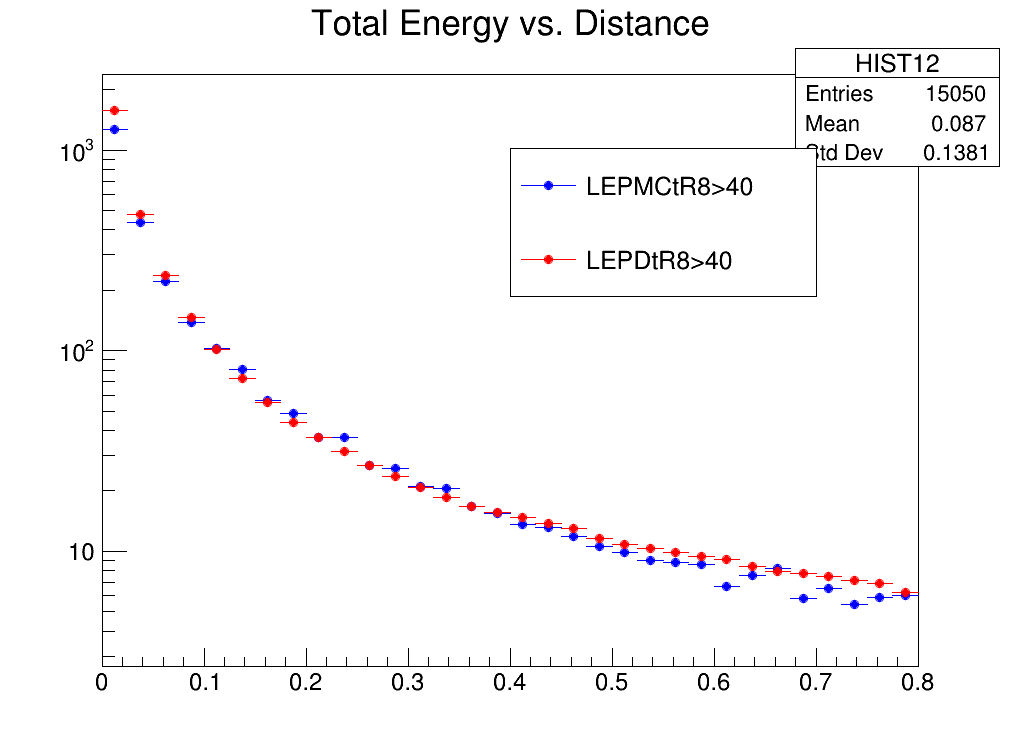

In [4]:
#Different simulations contrasted against the above code 
Canvas = ROOT.TCanvas("Canvas", "", 1024, 768)
Canvas.SetLogy()
File1 = ROOT.TFile("MC>40t.root")
#different simulation matchbox vs. sherpa vs. LEPIMC
#with and without detector effects which is LEPIMC with t and tgen two histograms
#everything under LEPIMC ALEPHMC
# with detector vs. data LEPIMC vs. LEPIData 
File2 = ROOT.TFile("LEPD>40t.root")
#File3 = ROOT.TFile("reconLEPMCtR8.root")

Hist1 = File1.Get("HIST12")
Hist2 = File2.Get("HIST12")
#Hist3 = File3.Get("HIST12")

Hist1.SetLineColor(ROOT.kBlue)
Hist2.SetLineColor(ROOT.kRed)
#Hist3.SetLineColor(ROOT.kGreen)

Legend = ROOT.TLegend(0.5, 0.8, 0.8, 0.6)
Legend.AddEntry(Hist1, "LEPMCtR8>40", "lp")
Legend.AddEntry(Hist2, "LEPDtR8>40", "lp")
#Legend.AddEntry(Hist3, "LEPMCR8", "lp")


Hist1.SetMarkerStyle(20)
Hist1.SetMarkerColor(ROOT.kBlue)
Hist2.SetMarkerStyle(20)
Hist2.SetMarkerColor(ROOT.kRed)
#Hist3.SetMarkerStyle(20)
#Hist3.SetMarkerColor(ROOT.kGreen)
Hist1.Draw();
Hist2.Draw("same")
#Hist3.Draw("same")

#Do everything with R8 and <0.8 distance 
#
Canvas.Draw()
Legend.Draw()

In [ ]:
#part 2 finding polar angle of the particle

In [ ]:
def GetPhi(x, y):
    if x == 0 and y > 0:
        return math.pi / 2

    if x == 0 and y < 0: 
        return (-(math.pi) / 2)

    if x > 0: 
        return np.arctan(y / x)

    if x < 0: 
        return math.pi + np.arctan(y / x)
    return 0

def jetshape(inputfilename, outputfilename, particletree1, particletree2):
    File = ROOT.TFile("LEP1MC1994_recons_aftercut-001.root")
    outFile = ROOT.TFile(outputfilename, "recreate")
    Hist12 = ROOT.TH1D("HIST12", "Total Energy vs. Distance", 80, 0, 20)
    Hist13 = ROOT.TH2D("HIST13", "E from tgen vs. E from t", 80, 0, 20, 80, 0, 20)
    Hist14 = ROOT.TH2D("HIST14", "polar theta from tgen vs. polar theta from t", 80, 0, 3.141, 80, -0.005, 0.005)
    Hist16 = ROOT.TH2D("HIST16", "azimuth from tgen vs. azimuth from t", 80, -3.141 / 2, 3.141 * 1.5, 80,-.05, 0.05)
    Counter = 0
    TreeParticle1 = File.Get(particletree1)
    TreeParticle2 = File.Get(particletree2)
    TotalNumberOfCollisions = TreeParticle1.GetEntries("nParticle")
    TargetNumberOfCollisions = TotalNumberOfCollisions * 0.01
    CurrentlyProcessed = 0
    for Event1, Event2 in zip(TreeParticle1, TreeParticle2):
         CurrentlyProcessed = CurrentlyProcessed + 1
         if CurrentlyProcessed > TargetNumberOfCollisions:
             break
        GenPX = [Event1.px[i] for i in range(Event1.nParticle)]
         GenPY = [Event1.py[i] for i in range(Event1.nParticle)]
         GenPZ = [Event1.pz[i] for i in range(Event1.nParticle)]
         GenP =  [math.sqrt(Event1.px[i] ** 2 + Event1.py[i] ** 2 + Event1.pz[i] ** 2) for i in range(Event1.nParticle)]
         GenE = [math.sqrt(Event1.mass[i]**2 + GenP[i]**2) for i in range(Event1.nParticle)]
         Gentheta = np.arccos([GenPZ[i] / math.sqrt(Event1.px[i] ** 2 + Event1.py[i] ** 2 + Event1.pz[i] ** 2) for i in range(Event1.nParticle)])
        #E1 Event1.charge[...] == 0 Event2.charge[...' ==0 all plots stay the same just adding a qualifier
         PGPX = [Event2.px[i] for i in range(Event2.nParticle)]
         PGPY = [Event2.py[i] for i in range(Event2.nParticle)]
         #print([ParticleGen.eta[i] for i in range(ParticleGen.nParticle)])
         PGPZ = [Event2.pz[i] for i in range(Event2.nParticle)]
         PGP = [math.sqrt(Event2.px[i] ** 2 + Event2.py[i] ** 2 + Event2.pz[i] ** 2) for i in range(Event2.nParticle)]
         PGE = [math.sqrt(Event2.mass[i]**2 + PGP[i]**2) for i in range(Event2.nParticle)]
         Ptheta = np.arccos([PGPZ[i] / math.sqrt(Event2.px[i] ** 2 + Event2.py[i] ** 2 + Event2.pz[i] ** 2) for i in range(Event2.nParticle)])
         #E1prime
         for iG in range(len(GenPX)):
             # we want to do both <40 and >40 want as well 10-20; 20-30; 30-40; 40+ (R8; MCt v. MCtgen) (MCtgen and Datat)
             if GenE [iG]< 1: 
                 continue
             Counter = Counter + 1
             Bestsofar = 0 
             Bestdistance = 9999
             for iP in range(Event2.nParticle):
                 if PGP[iP] == 0 or GenP[iG] == 0:
                     continue
                 Cosine = (((GenPX[iG] * PGPX[iP]) + (GenPY[iG] * PGPY[iP]) + (GenPZ[iG] * PGPZ[iP])) / (GenP[iG] * PGP[iP]))
                 if Cosine > 1: Cosine = 1
                 if Cosine < -1: Cosine = -1
                 Distance = np.arccos(Cosine)
                 if Distance < Bestdistance :
                     Bestsofar = iP
                     Bestdistance = Distance
                 Hist12.GetXaxis().SetRangeUser(0, 4)
             Hist12.Fill(Bestsofar)
             if Bestdistance < 0.04:
                 #Hist14.Fill(Gentheta[iG],Ptheta[Bestsofar] - Gentheta[iG])
                 #Hist16.Fill(GetPhi(GenPX[iG], GenPY[iG]),GetPhi( PGPX[Bestsofar], PGPY[Bestsofar]))
                 Hist16.Fill(GetPhi(GenPX[iG], GenPY[iG]),GetPhi( PGPX[Bestsofar], PGPY[Bestsofar])- GetPhi(GenPX[iG], GenPY[iG]))
    Hist12.Scale(1 / Counter)
    for i in range (0, 80):
        r = Hist12.GetXaxis(). GetBinLowEdge(i + 1)
        R = Hist12.GetXaxis().GetBinUpEdge(i + 1)
        x = Hist12.GetBinContent(i + 1)
        Area = math.pi*(R*R - r*r)
        avg = x / Area
        Hist12.SetBinContent(i + 1, avg)
    
    Canvas = ROOT.TCanvas("Canvas", "", 1024, 768)
    #Hist2.GetXaxis().SetRangeUser(0, 0.8)
    #Hist3.GetXaxis().SetRangeUser(0, 0.8)
    Hist12.Draw()
    #Canvas.SetLogy()
    #delete previous line when doing new type of running
    outFile.cd()
    Hist12.Write()
    Hist16.Write()
    outFile.Close()

#only need mct and mctgen

# goal: data
#step 2: undo detector effects 
#step 1: how big it is 
#step 3 test on simulation 
#step 4 systematic uncertainties
#need to know if simulation is similar to data 

In [ ]:
jetshape("LEP1MC1994_recons_aftercut-001.root", "MCbestdistancephi.root", "tgen", "t")

In [ ]:
Canvas = ROOT.TCanvas("Canvas", "", 1024, 768)
#Canvas.SetLogy()
File1 = ROOT.TFile("MCbestdistancephi.root")
#different simulation matchbox vs. sherpa vs. LEPIMC
#with and without detector effects which is LEPIMC with t and tgen two histograms
#everything under LEPIMC ALEPHMC
# with detector vs. data LEPIMC vs. LEPIData 
#File2 = ROOT.TFile("reconLEPMCtgenR8.root")
#File3 = ROOT.TFile("reconLEPMCtR8.root")

Hist1 = File1.Get("HIST16")
#Hist2 = File2.Get("HIST12")
#Hist3 = File3.Get("HIST12")

Hist1.SetLineColor(ROOT.kBlue)
#Hist2.SetLineColor(ROOT.kRed)
#Hist3.SetLineColor(ROOT.kGreen)

Legend = ROOT.TLegend(1, 1, 1, 0.6)
Legend.AddEntry(Hist1, "LEPMCtR8", "lp")
#Legend.AddEntry(Hist2, "LEPMCtgenR8", "lp")
#Legend.AddEntry(Hist3, "LEPMCR8", "lp")
Hist16.projectiony

Hist1.SetMarkerStyle(20)
Hist1.SetMarkerColor(ROOT.kBlue)
#Hist2.SetMarkerStyle(20)
#Hist2.SetMarkerColor(ROOT.kRed)
#Hist3.SetMarkerStyle(20)
#Hist3.SetMarkerColor(ROOT.kGreen)
Hist1.Draw("colz");
#Hist2.Draw("same")
#Hist3.Draw("same")

#Do everything with R8 and <0.8 distance 
#
Canvas.Draw()
Legend.Draw()